# Distribution Transformations

## INFO 442 Group 5 Shuyang Zhang

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PowerTransformer, StandardScaler, FunctionTransformer
from sklearn.model_selection import cross_val_score
from sklearn.base import BaseEstimator, TransformerMixin

diamonds = pd.read_csv('diamonds.csv')

### 1. Load the seaborn diamonds dataset. Check the skewness of price, carat, and depth. Which need transformation?

In [22]:
for col in ['price', 'carat', 'depth']:
    skew = diamonds[col].skew()
    print(f"{col:10s} skewness = {skew:+.4f}")
    if abs(skew) > 1:
        print(f"           -> Strong skew")
    elif abs(skew) > 0.5:
        print(f"           -> Moderate skew")
    else:
        print(f"           -> Approximately symmetric")

price      skewness = +1.6184
           -> Strong skew
carat      skewness = +1.1166
           -> Strong skew
depth      skewness = -0.0823
           -> Approximately symmetric


answer: price (skewness = +1.6184) and carat (skewness = +1.1166) need transformation due to strong positive skew. depth (skewness = -0.0823) is approximately symmetric and does not need transformation.

### 2. Apply Yeo-Johnson to all three columns inside a Pipeline with a Ridge regressor predicting log(price). Compare R² with and without the transformation.

In [28]:
X = diamonds[['price', 'carat', 'depth']].copy()
y = np.log1p(diamonds['price'])  

pipe_no_transform = Pipeline([
    ('scale', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

pipe_yj = Pipeline([
    ('yj', PowerTransformer(method='yeo-johnson')),
    ('scale', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

scores_no = cross_val_score(pipe_no_transform, X, y, cv=5, scoring='r2')
scores_yj = cross_val_score(pipe_yj, X, y, cv=5, scoring='r2')

print(f"Without transformation - R²: {scores_no.mean():.4f} +/- {scores_no.std():.4f}")
print(f"With Yeo-Johnson - R²: {scores_yj.mean():.4f} +/- {scores_yj.std():.4f}")
print(f"Improvement: {scores_yj.mean() - scores_no.mean():+.4f}")
print()

yj = PowerTransformer(method='yeo-johnson')
yj.fit(X)
print("Yeo-Johnson lambdas for each column:")
for col, lam in zip(['price', 'carat', 'depth'], yj.lambdas_):
    print(f"  {col}: {lam:.4f}")
print()

Without transformation - R²: 0.3599 +/- 0.3821
With Yeo-Johnson - R²: 0.9819 +/- 0.0151
Improvement: +0.6219

Yeo-Johnson lambdas for each column:
  price: -0.0674
  carat: -1.2501
  depth: 1.5677



answer: Yeo-Johnson transformation significantly improved R² from 0.3599 ± 0.3821 to 0.9819 ± 0.0151, an improvement of +0.622. The lambdas indicate that price (λ=-0.0674) is best approximated by log transform, carat (λ=-1.2501) by inverse transform, and depth (λ=1.5677) by square transform. 

### 3. What happens when you apply log1p to a feature that is already approximately normal (e.g. depth in diamonds)? Plot the Q-Q plot before and after.

Original depth skewness: -0.0823
After log1p skewness: -3.2411
log1p on already-normal data introduces negative skew - not recommended


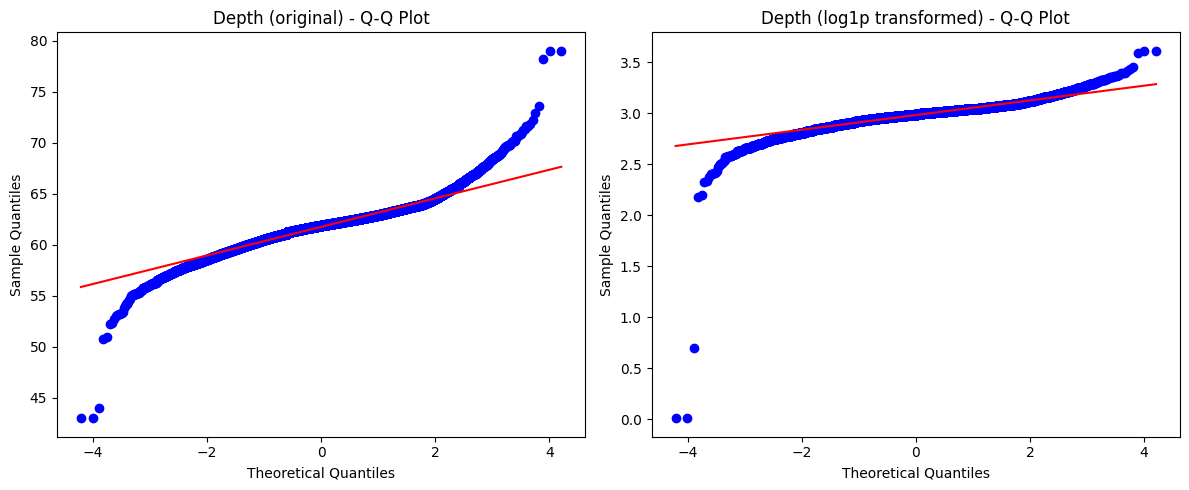

In [33]:
depth = diamonds['depth']
depth_log1p = np.log1p(depth - depth.min() + 0.01)  

print(f"Original depth skewness: {depth.skew():+.4f}")
print(f"After log1p skewness: {pd.Series(depth_log1p).skew():+.4f}")
print("log1p on already-normal data introduces negative skew - not recommended")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(depth, dist='norm', plot=axes[0])
axes[0].set_title('Depth (original) - Q-Q Plot')
axes[0].set_xlabel('Theoretical Quantiles')
axes[0].set_ylabel('Sample Quantiles')

stats.probplot(depth_log1p, dist='norm', plot=axes[1])
axes[1].set_title('Depth (log1p transformed) - Q-Q Plot')
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()


answer: Applying log1p to an approximately normal feature (depth, skewness -0.0823) created strong negative skew (-3.2411). The Q-Q plot shows points deviating from the diagonal after transformation, confirming that normality was harmed. This demonstrates that transformations should only be applied to skewed features; applying them to already-symmetric data degrades performance.

### 4. Implement a SkewnessSelector transformer that only applies PowerTransformer to columns whose |skewness| > 0.5 and passes other columns through unchanged.

In [38]:
class SkewnessSelector(BaseEstimator, TransformerMixin):

    def __init__(self, threshold=0.5, method='yeo-johnson'):
        self.threshold = threshold
        self.method = method
        self.feature_names_in_ = None
    
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.feature_names_in_ = X.columns.tolist()
        self.skewness_ = X.skew()
        self.transformers_ = {}
        self.passthrough_cols_ = []
        
        for col in X.columns:
            if abs(self.skewness_[col]) > self.threshold:
                self.transformers_[col] = PowerTransformer(method=self.method)
                self.transformers_[col].fit(X[[col]])
            else:
                self.passthrough_cols_.append(col)
        
        return self
    
    def transform(self, X):
        X = pd.DataFrame(X, columns=self.feature_names_in_)
        X_transformed = X.copy()
        
        for col, transformer in self.transformers_.items():
            X_transformed[col] = transformer.transform(X[[col]]).ravel()
        
        return X_transformed.values


X_test = diamonds[['price', 'carat', 'depth']].copy()
selector = SkewnessSelector(threshold=0.5)
selector.fit(X_test)
X_transformed = selector.transform(X_test)

print("Columns and their skewness:")
for col in ['price', 'carat', 'depth']:
    skew = selector.skewness_[col]
    transformed = col in selector.transformers_
    print(f"  {col}: skewness={skew:+.4f}, transformed={transformed}")

print(f"\nColumns transformed: {list(selector.transformers_.keys())}")
print(f"Columns passed through: {selector.passthrough_cols_}")

X_all = diamonds[['price', 'carat', 'depth']].copy()
y_target = np.log1p(diamonds['price'])

pipe_all = Pipeline([
    ('yj', PowerTransformer(method='yeo-johnson')),
    ('scale', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

pipe_selective = Pipeline([
    ('selector', SkewnessSelector(threshold=0.5)),
    ('scale', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

scores_all = cross_val_score(pipe_all, X_all, y_target, cv=5, scoring='r2')
scores_selective = cross_val_score(pipe_selective, X_all, y_target, cv=5, scoring='r2')

print(f"\nTransform all columns - R²: {scores_all.mean():.4f} +/- {scores_all.std():.4f}")
print(f"Transform only skewed columns - R²: {scores_selective.mean():.4f} +/- {scores_selective.std():.4f}")

Columns and their skewness:
  price: skewness=+1.6184, transformed=True
  carat: skewness=+1.1166, transformed=True
  depth: skewness=-0.0823, transformed=False

Columns transformed: ['price', 'carat']
Columns passed through: ['depth']

Transform all columns - R²: 0.9819 +/- 0.0151
Transform only skewed columns - R²: 0.9819 +/- 0.0151


answer: The SkewnessSelector correctly identified price (skewness +1.6184) and carat (skewness +1.1166) for transformation, while depth (skewness -0.0823) was passed through unchanged. Both approaches achieved identical R² (0.9819 ± 0.0151), proving that transforming already-symmetric features does not improve performance. The selector saves computation without sacrificing accuracy.